In [1]:
from one.api import ONE
from brainbox.io.one import SessionLoader
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from collections import defaultdict
import pandas as pd
from ibl_info.utils import check_config
import numpy as np
from matplotlib import pyplot as plt
from glob import glob
import pickle as pkl
from scipy import stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns
from manifold.utils import *
from glob import glob

In [2]:
%load_ext autoreload 
%autoreload 2

In [3]:
# load widefield
# check which regions carry significant information about stimulus and choice

In [4]:
# for each animal
# we load the three tables
# look at differences in accuracy

In [5]:
one = ONE(mode="local")
sessions_all = one.search(datasets="widefieldU.images.npy")
sessions_all = np.asarray([str(s) for s in sessions_all])  # type: ignore

In [7]:
df = pd.DataFrame(sessions_all,columns=['eid'])

In [10]:
w = pd.read_parquet('../data/raw/wifieids.pqt')

In [11]:
w

,eid
0,f7d46a15-9498-40dc-90da-fb977ce844be
1,2864dca1-38d8-464c-9777-f6fdfd5e63b5
2,5102bc6c-e8d5-494b-a227-8fb15ef983ff
3,b83033ed-c5d0-4e49-a595-0a04c48f059d
4,501ba50d-73ba-44ec-8782-ef1fa6881044
5,fa9dabe2-f6bf-4522-ba33-7d7240f9b2c9
6,b69895df-382b-4d3f-bf16-f4eff019b470
7,31c9782b-da54-46d0-a257-25f06bc4e5e8
8,be184bc8-37fb-494c-9fcf-619b10384018
9,2cdac946-3a62-458e-9060-57466f4c6bda


In [6]:
# load one pickle and get all regions

temp_pickle = pkl.load(open("../data/generated/wifi/choice/responsetime/12046ccd-b737-4c01-bc70-400f3b69291b_choice_None.pkl","rb"))
all_regions = np.asarray(list(temp_pickle['choice-2'].keys()))


In [ ]:
global_accuracies = {}
for rx in all_regions:
    accuracies = []
    for idx, eid in enumerate(sessions_all):  # type: ignore
        if eid=='6dde46d9-2d48-4f01-a107-47d68d981720':
            continue
        try:
            data_choice = pkl.load(open(f"../data/generated/wifi/choice/responsetime/{eid}_choice_None.pkl", "rb"))
            accuracies.append(
                    data_choice['choice-2'][rx]["mean_score"],
            )
        except Exception as e:
            # print(e)
            # print(eid, idx)
            accuracies.append(0)
            continue
    global_accuracies[rx] = accuracies
region_to_high_acc_eids = defaultdict(list)
eid_to_high_acc_regions = defaultdict(list)

ACCURACY_THRESHOLD = .55 

for rx in all_regions:
    for idx, eid in enumerate(sessions_all): 
        if eid == '6dde46d9-2d48-4f01-a107-47d68d981720':
            continue
            
        try:
            data_choice = pkl.load(open(f"../data/generated/wifi/choice/responsetime/{eid}_choice_None.pkl", "rb"))
            acc = data_choice['choice-2'][rx]["mean_score"]
            
            # If it crosses the threshold, record it in both mappings
            if acc > ACCURACY_THRESHOLD:
                region_to_high_acc_eids[rx].append(eid)
                eid_to_high_acc_regions[eid].append(rx)
                
        except Exception as e:
            # If a file is missing or corrupted, we simply skip it. 
            # We no longer need to append 0, because it wouldn't pass the >55 threshold anyway.
            print(e)
            continue

# Convert back to standard dictionaries (optional, but cleaner for viewing)
region_to_high_acc_eids = dict(region_to_high_acc_eids)
eid_to_high_acc_regions = dict(eid_to_high_acc_regions)

np.str_('TEa')
np.str_('AUDp')
np.str_('AUDp')
np.str_('AUDp')
np.str_('AUDp')


Text(0, 0.5, 'Decoding accuracy: Choice')

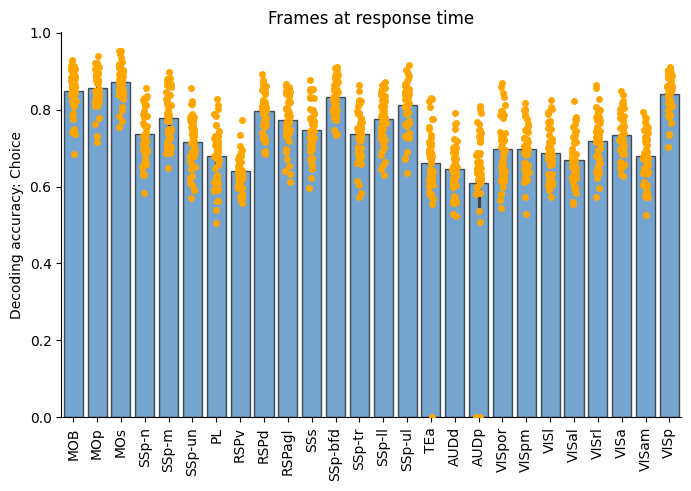

In [55]:
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(df, color="#1476cd",alpha=0.65, edgecolor='k')
sns.stripplot(df,color='orange',edgecolor='k')
ax.set_xticks(np.arange(len(all_regions)),all_regions, rotation=90)
sns.despine()
ax.set_title(f'Frames at response time')
ax.set_ylabel('Decoding accuracy: Choice')

In [7]:
global_accuracies = {}
for rx in all_regions:
    accuracies = []
    for idx, eid in enumerate(sessions_all):  # type: ignore
        if eid=='6dde46d9-2d48-4f01-a107-47d68d981720':
            continue
        try:
            data_delta = pkl.load(open(f"../data/generated/wifi/diff_stim/{eid}_stim.pkl", "rb"))
            data_stim_zero = pkl.load(
                open(f"../data/generated/wifi/stim_intervals/stim1/{eid}_stim-1.pkl", "rb")
            )
            data_stim_one = pkl.load(
                open(f"../data/generated/wifi/stim_intervals/stim2/{eid}_stim-2.pkl", "rb")
            )
            accuracies.append(
                [
                    data_delta[rx]["mean_score"],
                    data_stim_zero[rx]["mean_score"],
                    data_stim_one[rx]["mean_score"],
                ]
            )
        except Exception as e:
            print(e)
            print(eid, idx)
            accuracies.append([0, 0, 0])
    global_accuracies[rx] = accuracies

np.str_('TEa')
ba198a10-4918-41d7-8395-fee53eeb6a0a 18
np.str_('AUDp')
ba198a10-4918-41d7-8395-fee53eeb6a0a 18
np.str_('AUDp')
2c3abfbf-1871-4af0-8b8a-f337ac53b3fa 20
np.str_('AUDp')
d34a502f-bd06-471f-8334-df41f785e1d9 27
np.str_('AUDp')
8d098f4f-8067-4a17-8755-b3698e724d5d 32


In [7]:
def get_star_rating(p):
    if p >= 0.05:
        return "ns"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    else:
        return "*"


def check_significance(df):
    columns = df.columns.tolist()
    pairs = [
        (columns[0], columns[1]),
        (columns[1], columns[2]),
        (columns[0], columns[2]),
    ]
    sig_flag_all = []
    for col1, col2 in pairs:
        # Wilcoxon signed-rank test since data is paired across epochs per animal
        _, p_raw = stats.wilcoxon(df[col1], df[col2], alternative="two-sided")
        test_name = "Wilcoxon"

        p_corrected = min(1.0, p_raw * 3)  # type: ignore
        # status = "SIGNIFICANT" if p_corrected < 0.05 else "NOT SIGNIFICANT"
        sig_flag = get_star_rating(p_corrected)
        sig_flag_all.append(sig_flag)

    return sig_flag_all

In [ ]:
for region_name in global_accuracies.keys():
    w = np.asarray(global_accuracies[region_name])
    df = pd.DataFrame(w, columns=["delta", "0", "1"])
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(df, ax=ax)
    sns.stripplot(df, ax=ax)
    sns.despine()
    ax.set_ylim(0, 0.8)

    result = check_significance(df)
    ax.set_title(f"{region_name}, {result}")

In [100]:
# let's use the activity at frame 1

In [8]:
dfs = pd.DataFrame(global_accuracies)

In [19]:
# do stats
# so what do we do
# for each animal, find significant region
# then we combine 
# we can use the pseudosession thing from the diff to set the limits

import scipy.stats as stats
import statsmodels.stats.multitest as smm

In [20]:
def build_data_dict(all_regions, sessions_all):
    data_dict = {}
    for rx in all_regions:
        data_dict[rx] = {}
        for idx, eid in enumerate(sessions_all):
            if eid == "6dde46d9-2d48-4f01-a107-47d68d981720":
                continue
            try:
                # Load true scores
                data_delta = pkl.load(open(f"../data/generated/wifi/diff_stim/{eid}_stim.pkl", "rb"))
                data_stim_zero = pkl.load(open(f"../data/generated/wifi/stim_intervals/stim1/{eid}_stim-1.pkl", "rb"))
                data_stim_one = pkl.load(open(f"../data/generated/wifi/stim_intervals/stim2/{eid}_stim-2.pkl", "rb"))
                
                
                data_dict[rx][eid] = {
                    'delta': data_delta[rx]["mean_score"],
                    'stim1': data_stim_zero[rx]["mean_score"],
                    'stim2': data_stim_one[rx]["mean_score"],
                    'null_delta': data_delta[rx]['pseudoessions']
                }
            except Exception as e:
                print(f"Skipping {eid} for {rx} due to error: {e}")
                continue
    return data_dict

In [21]:
def evaluate_region_significance(data_dict, score_condition='delta', alpha=0.05):
    """
    Parameters:
    - data_dict: Nested dictionary [region][eid] containing scores and nulls.
    - score_condition: Which true score to use ('delta', 'stim1', or 'stim2').
    - alpha: Significance threshold.
    """
    results = {}
    regions_list = []
    p_vals_for_correction = []

    for rx, eids_data in data_dict.items():
        animal_pvals_list = []  # Needed for Fisher's method
        animal_pvals_dict = {}  # NEW: Map eid to exact p-value
        significant_eids = []   # NEW: Store eids that pass alpha
        
        for eid, metrics in eids_data.items():
            true_score = metrics[score_condition]
            null_dist = np.array(metrics['null_delta'])
            
            if true_score is None or null_dist is None or len(null_dist) == 0:
                continue 
                
            p_val = (np.sum(null_dist >= true_score) + 1) / (len(null_dist) + 1)
            
            # Track the data
            animal_pvals_list.append(p_val)
            animal_pvals_dict[eid] = p_val
            
            if p_val < alpha:
                significant_eids.append(eid)

        if not animal_pvals_list:
            continue

        stat, combined_p = stats.combine_pvalues(animal_pvals_list, method='fisher')

        regions_list.append(rx)
        p_vals_for_correction.append(combined_p)
        
        results[rx] = {
            'combined_p': combined_p,
            'animal_pvals': animal_pvals_dict,       # Upgraded to dictionary
            'significant_eids': significant_eids,    # Added direct list
            'n_animals_sig': len(significant_eids),
            'n_animals_total': len(animal_pvals_list)
        }

    if not p_vals_for_correction:
        return results

    # FDR Correction
    reject_fdr, pvals_fdr, _, _ = smm.multipletests(
        p_vals_for_correction, alpha=alpha, method='fdr_bh'
    )
    
    # Bonferroni Correction
    reject_bonf, pvals_bonf, _, _ = smm.multipletests(
        p_vals_for_correction, alpha=alpha, method='bonferroni'
    )

    for i, rx in enumerate(regions_list):
        results[rx]['p_fdr_corrected'] = pvals_fdr[i]
        results[rx]['survives_fdr'] = reject_fdr[i]
        results[rx]['p_bonferroni_corrected'] = pvals_bonf[i]
        results[rx]['survives_bonferroni'] = reject_bonf[i]

    return results

In [22]:
data_dict_all = build_data_dict(all_regions, sessions_all)

Skipping ba198a10-4918-41d7-8395-fee53eeb6a0a for TEa due to error: np.str_('TEa')
Skipping ba198a10-4918-41d7-8395-fee53eeb6a0a for AUDp due to error: np.str_('AUDp')
Skipping 2c3abfbf-1871-4af0-8b8a-f337ac53b3fa for AUDp due to error: np.str_('AUDp')
Skipping d34a502f-bd06-471f-8334-df41f785e1d9 for AUDp due to error: np.str_('AUDp')
Skipping 8d098f4f-8067-4a17-8755-b3698e724d5d for AUDp due to error: np.str_('AUDp')


In [23]:
stats_results = evaluate_region_significance(data_dict_all, score_condition='delta')
stats_results = pd.DataFrame(stats_results)

In [24]:
stats_results

,MOB,MOp,MOs,SSp-n,SSp-m,SSp-un,PL,RSPv,RSPd,RSPagl,...,AUDd,AUDp,VISpor,VISpm,VISl,VISal,VISrl,VISa,VISam,VISp
combined_p,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
animal_pvals,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.004...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.009...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.004...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.621...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.079...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.203...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.184...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.169...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.283...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.407...,...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.213...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.656...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.611...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.791...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.393...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.084...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.965...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.039...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.965...,{'f7d46a15-9498-40dc-90da-fb977ce844be': 0.009...
significant_eids,"[f7d46a15-9498-40dc-90da-fb977ce844be, 2864dca...","[f7d46a15-9498-40dc-90da-fb977ce844be, 5102bc6...","[f7d46a15-9498-40dc-90da-fb977ce844be, 5102bc6...","[5102bc6c-e8d5-494b-a227-8fb15ef983ff, b83033e...","[5102bc6c-e8d5-494b-a227-8fb15ef983ff, b83033e...","[2864dca1-38d8-464c-9777-f6fdfd5e63b5, 5102bc6...","[b83033ed-c5d0-4e49-a595-0a04c48f059d, fa9dabe...","[b83033ed-c5d0-4e49-a595-0a04c48f059d, fa9dabe...","[5102bc6c-e8d5-494b-a227-8fb15ef983ff, b83033e...","[5102bc6c-e8d5-494b-a227-8fb15ef983ff, b83033e...",...,"[2864dca1-38d8-464c-9777-f6fdfd5e63b5, b83033e...","[2864dca1-38d8-464c-9777-f6fdfd5e63b5, b83033e...","[b83033ed-c5d0-4e49-a595-0a04c48f059d, 501ba50...","[2864dca1-38d8-464c-9777-f6fdfd5e63b5, 5102bc6...","[5102bc6c-e8d5-494b-a227-8fb15ef983ff, b83033e...","[2864dca1-38d8-464c-9777-f6fdfd5e63b5, 5102bc6...","[2864dca1-38d8-464c-9777-f6fdfd5e63b5, 5102bc6...","[f7d46a15-9498-40dc-90da-fb977ce844be, 2864dca...","[2864dca1-38d8-464c-9777-f6fdfd5e63b5, 5102bc6...","[f7d46a15-9498-40dc-90da-fb977ce844be, 2864dca..."
n_animals_sig,39,34,40,15,23,16,17,16,25,28,...,15,17,22,31,33,34,36,32,25,45
n_animals_total,49,49,49,49,49,49,49,49,49,49,...,49,45,49,49,49,49,49,49,49,49
p_fdr_corrected,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
survives_fdr,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
p_bonferroni_corrected,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
survives_bonferroni,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


In [25]:
from collections import defaultdict

# Initialize a defaultdict where every new key automatically starts with an empty list
eid_to_regions = defaultdict(list)

# Invert the dictionary
for rx, metrics in stats_results.items():
    for eid in metrics.get('significant_eids', []):
        eid_to_regions[eid].append(rx)

# Convert back to a standard dictionary (optional, but good for clean printing)
eid_to_regions = dict(eid_to_regions)

In [42]:
eids_with_significant_stim_and_choice = {}

In [45]:
for key in eid_to_regions.keys():
    stim_regions = [str(x) for x in eid_to_regions[key]]
    choice_regions = [str(x) for x in eid_to_high_acc_regions[key]]
    temp = {    }
    temp['stim'] = stim_regions
    temp['choice'] = choice_regions
    eids_with_significant_stim_and_choice[key] = temp


In [47]:
with open('../data/processed/significant_stims_choice.pkl','wb') as f:
    pkl.dump(eids_with_significant_stim_and_choice,f) 

In [ ]:
eid_to_regions

In [ ]:
eid_to_high_acc_regions

In [41]:
eid_to_high_acc_regions

{np.str_('f7d46a15-9498-40dc-90da-fb977ce844be'): [np.str_('MOB'),
  np.str_('MOp'),
  np.str_('MOs'),
  np.str_('SSp-n'),
  np.str_('SSp-m'),
  np.str_('SSp-un'),
  np.str_('PL'),
  np.str_('RSPv'),
  np.str_('RSPd'),
  np.str_('RSPagl'),
  np.str_('SSs'),
  np.str_('SSp-bfd'),
  np.str_('SSp-tr'),
  np.str_('SSp-ll'),
  np.str_('SSp-ul'),
  np.str_('TEa'),
  np.str_('AUDd'),
  np.str_('AUDp'),
  np.str_('VISpor'),
  np.str_('VISpm'),
  np.str_('VISl'),
  np.str_('VISal'),
  np.str_('VISrl'),
  np.str_('VISa'),
  np.str_('VISam'),
  np.str_('VISp')],
 np.str_('2864dca1-38d8-464c-9777-f6fdfd5e63b5'): [np.str_('MOB'),
  np.str_('MOp'),
  np.str_('MOs'),
  np.str_('SSp-n'),
  np.str_('SSp-m'),
  np.str_('SSp-un'),
  np.str_('RSPv'),
  np.str_('RSPd'),
  np.str_('RSPagl'),
  np.str_('SSs'),
  np.str_('SSp-bfd'),
  np.str_('SSp-tr'),
  np.str_('SSp-ll'),
  np.str_('SSp-ul'),
  np.str_('TEa'),
  np.str_('AUDd'),
  np.str_('AUDp'),
  np.str_('VISpor'),
  np.str_('VISpm'),
  np.str_('VISl'),


In [39]:
def plot_decoding_results(df_scores, df_frac,figsize=(15,10)):
   
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=figsize, 
                                   sharex=True, 
                                   gridspec_kw={'height_ratios': [2.5, 1]})

   
    sns.barplot(
        data=df_scores, 
        x='Region', 
        y='Balanced Accuracy Score', 
        ax=ax1, 
        color='#98B9D2',    
        edgecolor='dimgrey', 
        errorbar='sd',      
        capsize=0.1,        
        err_kws={'linewidth': 1.5, 'color': 'dimgrey'},
        zorder=1            
    )

   
    sns.stripplot(
        data=df_scores, 
        x='Region', 
        y='Balanced Accuracy Score', 
        ax=ax1, 
        color='#FF8C00', 
        edgecolor='dimgrey', 
        linewidth=0.8,   
        size=5, 
        jitter=0.25,     
        zorder=2
    )

    # 3. Add chance level line
    ax1.axhline(0.5, color='red', linestyle='--', zorder=0)
    
    # 4. Formatting top plot
    ax1.set_ylim(0.3, 1.0)
    ax1.set_title('Decoding Accuracy', fontsize=16, pad=15)
    ax1.set_xlabel('')   
    ax1.tick_params(axis='x', bottom=False) 

    
    sns.barplot(
        data=df_frac, 
        x='Region', 
        y='Fraction Significant', 
        ax=ax2, 
        color='#7495B3',    
        edgecolor='dimgrey'
    )
    
    
    ax2.set_ylim(0.0, 1.0)
    ax2.set_xlabel('Regions', fontsize=12, labelpad=10)
    
    
    ax2.tick_params(axis='x', rotation=90)
    sns.despine(ax=ax1)
    sns.despine(ax=ax2)
    
    plt.tight_layout()
    plt.show()

In [29]:
score_condition = 'delta'
scores_list = []
frac_list = []


for rx, metrics in stats_results.items():
    
    for eid, animal_data in data_dict_all[rx].items():
        score = animal_data[score_condition]
        if score is not None:
            scores_list.append({
                'Region': rx,
                'Balanced Accuracy Score': score
            })
            
    fraction_sig = metrics['n_animals_sig'] / metrics['n_animals_total']
    frac_list.append({
        'Region': rx,
        'Fraction Significant': fraction_sig
    })

df_scores = pd.DataFrame(scores_list)
df_frac = pd.DataFrame(frac_list)

In [31]:
df_scores.Region.unique()

array([np.str_('MOB'), np.str_('MOp'), np.str_('MOs'), np.str_('SSp-n'),
       np.str_('SSp-m'), np.str_('SSp-un'), np.str_('PL'),
       np.str_('RSPv'), np.str_('RSPd'), np.str_('RSPagl'),
       np.str_('SSs'), np.str_('SSp-bfd'), np.str_('SSp-tr'),
       np.str_('SSp-ll'), np.str_('SSp-ul'), np.str_('TEa'),
       np.str_('AUDd'), np.str_('AUDp'), np.str_('VISpor'),
       np.str_('VISpm'), np.str_('VISl'), np.str_('VISal'),
       np.str_('VISrl'), np.str_('VISa'), np.str_('VISam'),
       np.str_('VISp')], dtype=object)

In [37]:
temp_scores = df_scores[df_scores['Region'].isin(['MOB','MOp','MOs','VISpm','VISpor','VISl','VISal','VISa','VISam','VISrl','VISp'])]
temp_fracs = df_frac[df_frac['Region'].isin(['MOB','MOp','MOs','VISpm','VISpor','VISl','VISal','VISa','VISam','VISrl','VISp'])]

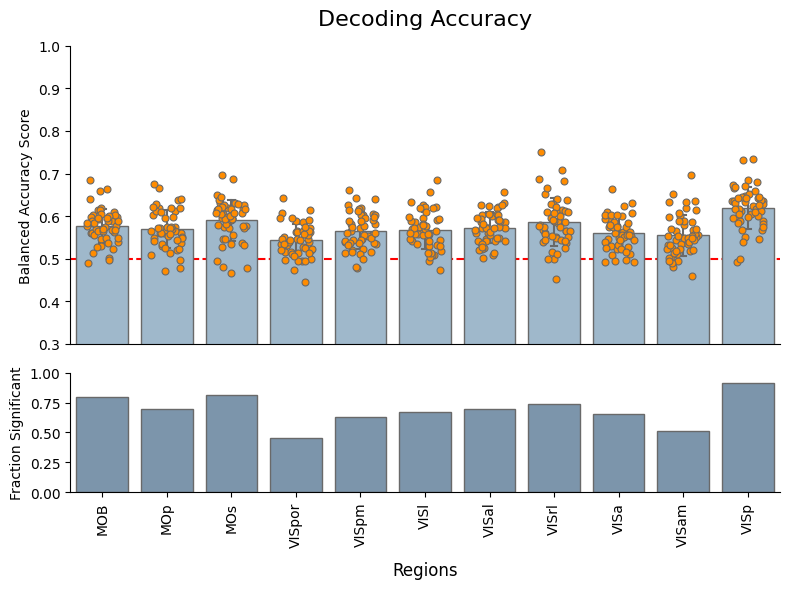

In [40]:
plot_decoding_results(temp_scores, temp_fracs,figsize=(8,6))

In [31]:
q = []
w=[]
for session_id in sessions_all:

    ssl = SessionLoader(one, session_id)
    ssl.load_trials(collection="alf")
    trials = ssl.trials.copy()

    out = np.nan_to_num(trials.contrastLeft) - np.nan_to_num(trials.contrastRight)
    trials["signcont"] = out
    trials["stim_side"] = np.sign(trials["signcont"])

    _, choice_behavioral_mask = load_trials_and_mask(
            one,
            session_id,
            exclude_nochoice=True,
            exclude_unbiased=False,
        )
    mask = choice_behavioral_mask
    trials_df = trials[mask]

    firstmovement = trials_df['firstMovement_times']-trials_df['stimOn_times']
    trials_df = trials_df[firstmovement>0]
    firstmovement = trials_df['firstMovement_times']-trials_df['stimOn_times']
    reactiontime = trials_df['response_times']-trials_df['stimOn_times'] 
    q.append(firstmovement.values)
    w.append(reactiontime.values)
q = np.concatenate(q)
w = np.concatenate(w)


In [45]:
bin_width = 0.066


min_val = min(q.min(), w.min())
max_val = max(q.max(), q.max())


min_edge = np.floor(min_val / bin_width) * bin_width
max_edge = np.ceil(max_val / bin_width) * bin_width

bins = np.arange(min_edge, max_edge + bin_width, bin_width)

Text(0.5, 1.0, 'First movement and response time across all animals')

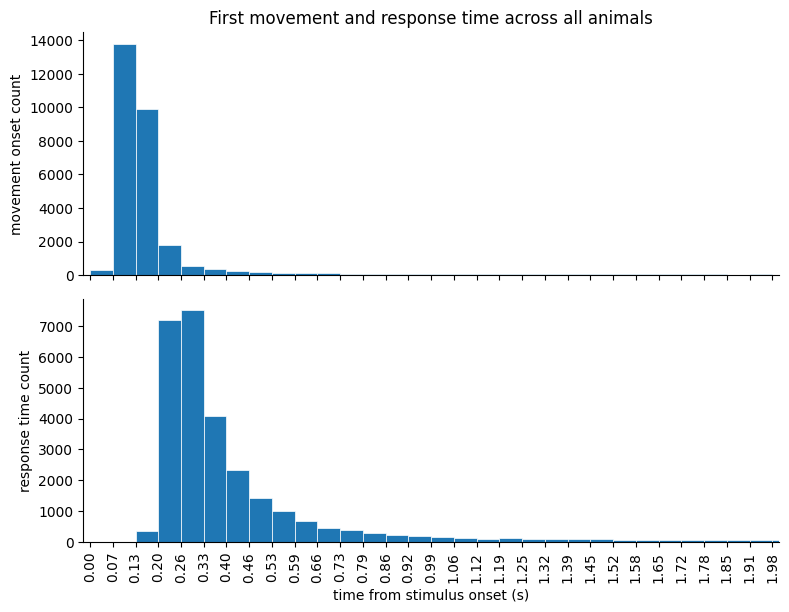

In [65]:
# Create stacked subplots sharing the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))


ax1.hist(q, bins=bins, edgecolor='white', linewidth=0.5)
ax1.set_ylabel('movement onset count')


ax2.hist(w, bins=bins, edgecolor='white', linewidth=0.5)
ax2.set_ylabel('response time count')
ax2.set_xlabel('time from stimulus onset (s)')


# --- Format X-Axis ---
# Set ticks exactly at the bin edges
ax2.set_xticks(bins)
# Format labels to 2 decimal places to match your reference image
ax2.set_xticklabels([f"{x:.2f}" for x in bins],rotation=90
                    )
ax2.set_xlim([-0.02, 2.0])
# Adjust layout to remove the gap between plots
plt.subplots_adjust(hspace=0.1)
plt.tight_layout()
sns.despine()
ax1.set_title('First movement and response time across all animals')


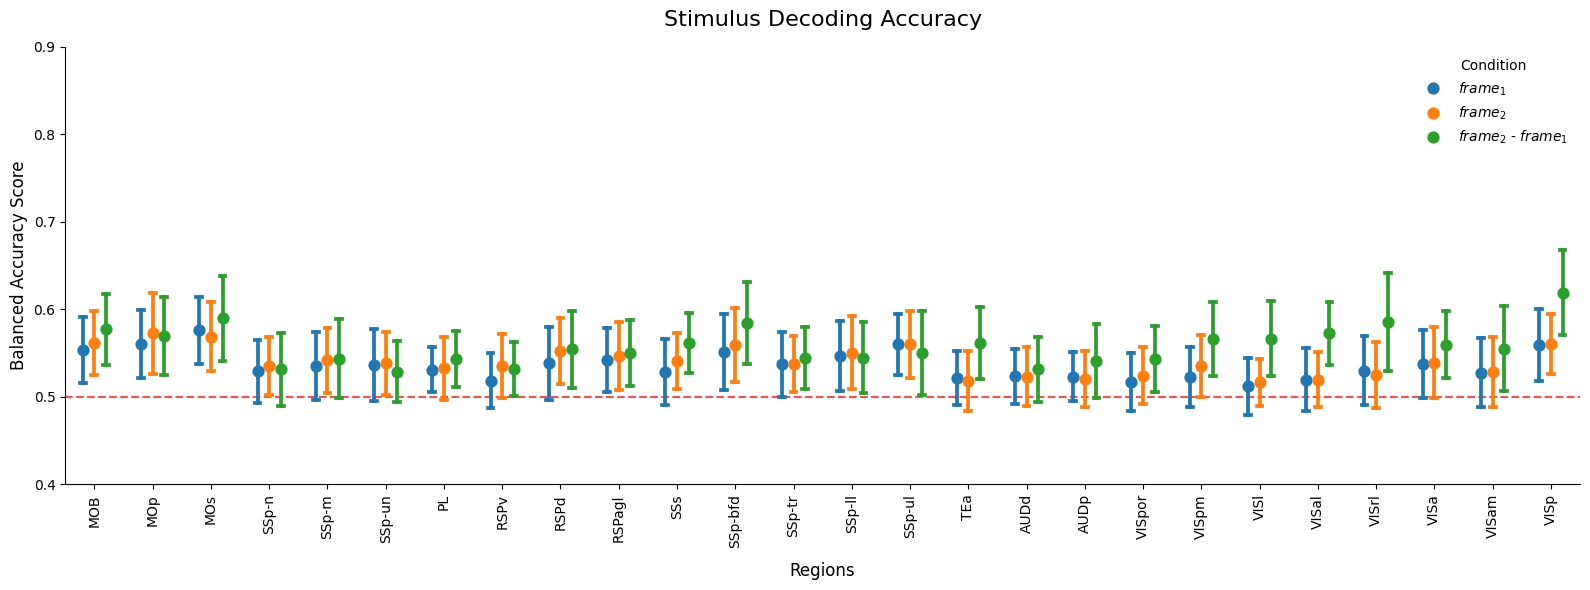

In [95]:
# point plots?
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

rows = []
# Assuming global_accuracies[rx] = [[delta_1, stim0_1, stim1_1], [delta_2, stim0_2, stim1_2], ...]
for rx, animal_scores in global_accuracies.items():
    for idx, scores in enumerate(animal_scores):
        # Skip failed loads (where you appended [0,0,0])
        if scores == [0, 0, 0]:
            continue
            
        rows.append({
            'Region': rx,
            'Animal': idx,
            '$frame_2$ - $frame_1$': scores[0],
            '$frame_1$': scores[1],
            '$frame_2$': scores[2]
        })

df_wide = pd.DataFrame(rows)


df_long = pd.melt(
    df_wide, 
    id_vars=['Region', 'Animal'], 
    value_vars=['$frame_1$', '$frame_2$', '$frame_2$ - $frame_1$'],
    var_name='Condition', 
    value_name='Accuracy'
)


def plot_three_conditions(df):
    fig, ax = plt.subplots(figsize=(16, 6))


    # palette = {"stim-1": "#4C72B0", "stim-2": "#DD8452", "delta": "#55A868"}


    sns.pointplot(
        data=df,
        x='Region',
        y='Accuracy',
        hue='Condition',
        # palette=palette,
        errorbar='sd',       # Show standard deviation
        dodge=0.4,           # Separate the 3 conditions per region
        # join=False,          # Don't draw lines between regions (they aren't time series)
        capsize=0.1,         # Small caps on error bars
        ax=ax,
        linestyle="none",
    )

    # Add the chance level line
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, zorder=0)

    # Formatting
    ax.set_ylim(0.4, 0.9)
    ax.set_title('Stimulus Decoding Accuracy', fontsize=16, pad=15)
    ax.set_ylabel('Balanced Accuracy Score', fontsize=12)
    ax.set_xlabel('Regions', fontsize=12, labelpad=10)
    ax.tick_params(axis='x', rotation=90)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title='Condition', frameon=False, loc='upper right')

    sns.despine()
    
    plt.tight_layout()
    plt.show()

plot_three_conditions(df_long)


In [101]:
stats_results = evaluate_region_significance(data_dict_all, score_condition='stim1')
df_prime = pd.DataFrame(stats_results)
a = df_prime.loc['n_animals_sig'].values
stats_results = evaluate_region_significance(data_dict_all, score_condition='stim2')
df_prime = pd.DataFrame(stats_results)
b = df_prime.loc['n_animals_sig'].values
stats_results = evaluate_region_significance(data_dict_all, score_condition='delta')
df_prime = pd.DataFrame(stats_results)
c = df_prime.loc['n_animals_sig'].values


In [109]:
X = np.stack([a,b,c]) # type: ignore

In [125]:
df_wide = pd.DataFrame(X.T, columns=['$frame_1$', '$frame_2$', '$frame_1 - frame_2$'])
df_wide['Region'] = all_regions

# Melt into long format
df_long = pd.melt(
    df_wide, 
    id_vars=['Region'], 
    value_vars=['$frame_1$', '$frame_2$', '$frame_1 - frame_2$'],
    var_name='Condition', 
    value_name='Significant Animals'
)



In [128]:
df_long['Significant Animals'] = df_long['Significant Animals']/49

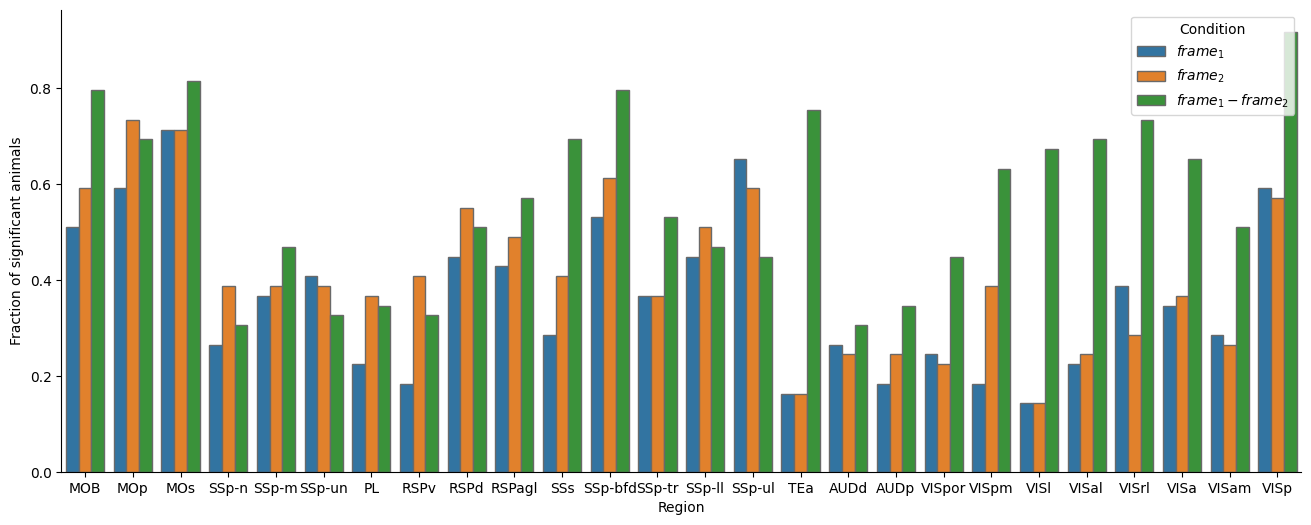

In [130]:
fig, ax = plt.subplots(figsize=(16, 6))

sns.barplot(
    data=df_long,
    x='Region',
    y='Significant Animals',
    hue='Condition',
    # palette=palette,
    edgecolor='dimgrey', # Adds a clean border to the bars
    ax=ax
)
ax.set_ylabel('Fraction of significant animals')
sns.despine()

In [135]:
file_list = glob("../data/generated/wifi/*_correlations.pkl")

In [145]:
regions_complete = []
for files in file_list:
    correlation_data = pkl.load(open(files,'rb'))
    region_animal = {}
    for r in correlation_data.keys():
        values = []
        for k in correlation_data[r].keys():
            values.append(correlation_data[r][k][0])
        region_animal[r] = values
    regions_complete.append(region_animal)
        

In [174]:
def plot_all_epochs_by_region(sessions_list):
    records = []
    
    for session_idx, session_data in enumerate(sessions_list):
        for region, epoch_array in session_data.items():
            for epoch_idx, corr_value in enumerate(epoch_array):

                if epoch_idx==0:
                    name = 'stim frame 1'
                elif epoch_idx==1:
                    name = 'stim frame 2'
                elif epoch_idx == 2:
                    name = 'choice frame 0'
                else:
                    name ='choice frame 1'
                records.append({
                    'Session': session_idx,
                    'Region': region,
                    'Epoch': f'{name}', # e.g., 'Epoch 0'
                    'Correlation': corr_value
                })
                
    df = pd.DataFrame(records)
    fig, ax = plt.subplots(figsize=(18, 7))


    palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]


    sns.boxplot(
        data=df,
        x='Region',
        y='Correlation',
        hue='Epoch',
        palette=palette,
        linewidth=1.2,
        fliersize=3,        # Make outlier dots slightly smaller
        boxprops={'alpha': 0.8}, # Slight transparency looks modern
        ax=ax
    )

    # 3. Formatting
    ax.set_ylim(0, 1.05)
    ax.set_title('Correlations', fontsize=16, pad=15)
    ax.set_ylabel('Correlation', fontsize=12)
    ax.set_xlabel('Regions', fontsize=12, labelpad=10)
    ax.tick_params(axis='x', rotation=45)

    # Clean up legend and borders
    ax.legend(title='Epoch Index', frameon=False, loc='lower right', bbox_to_anchor=(1.0, 1.0))
    sns.despine()

    plt.tight_layout()
    plt.show()





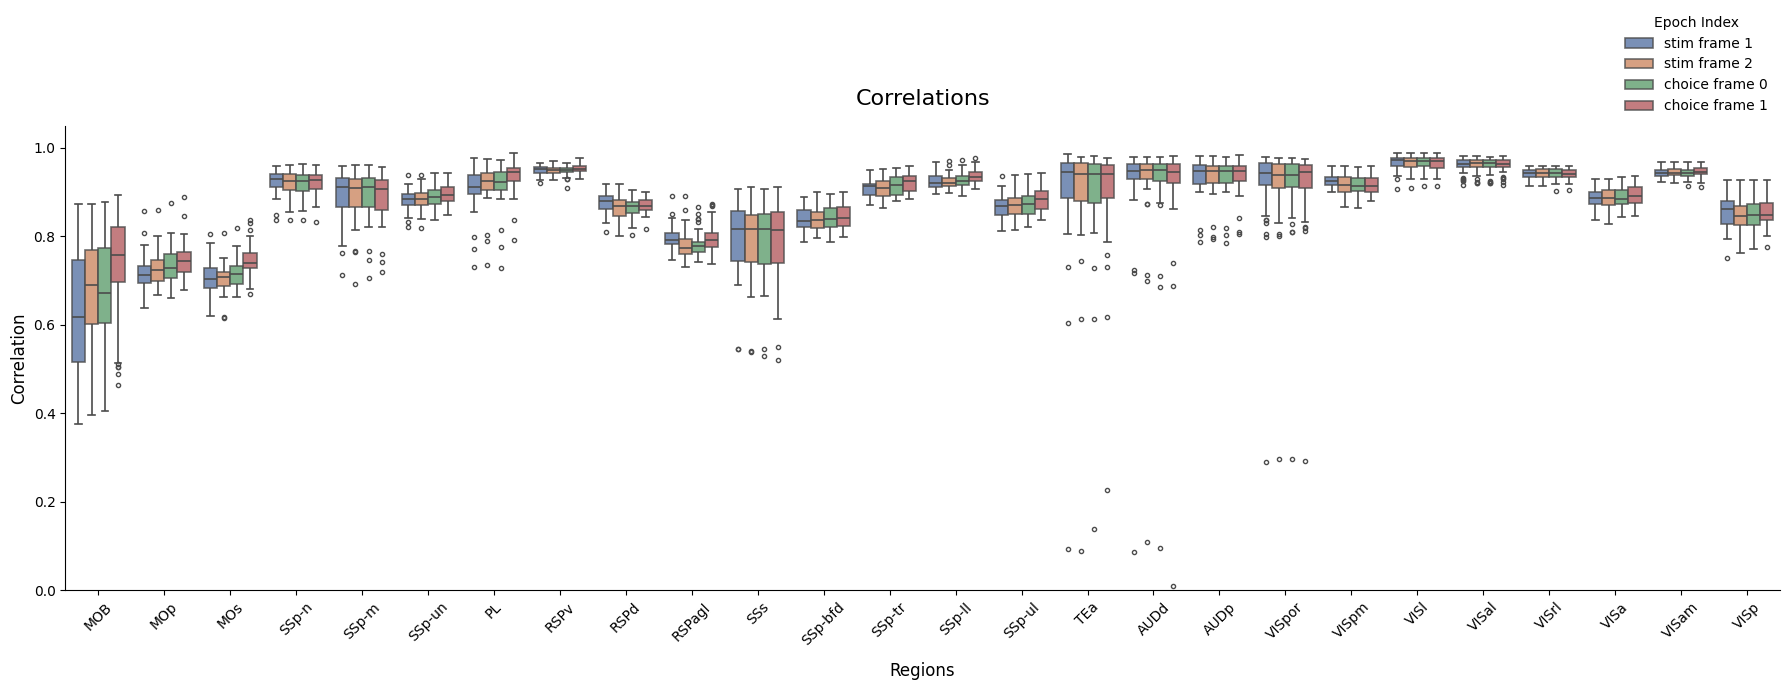

In [175]:
plot_all_epochs_by_region(regions_complete)